In [2]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch


In [3]:
def run_posthoc_analysis(df_diff, label_name):
    """
    Führt deskriptive Statistiken, gepaarte t-Tests und Cohen's d 
    für jeden Block (pair) in einem gepivotteten DataFrame aus.
    """
    stats_list = []

    required_cols = ['pair', 'delay', 'no_delay', 'diff']
    if not all(col in df_diff.columns for col in required_cols):
        print(f"Fehler: DataFrame für {label_name} enthält nicht alle benötigten Spalten.")
        return None

    for p in sorted(df_diff['pair'].unique()):
        pair_data = df_diff[df_diff['pair'] == p].dropna()
        
        m_no_delay = pair_data['no_delay'].mean()
        sd_no_delay = pair_data['no_delay'].std()
        m_delay = pair_data['delay'].mean()
        sd_delay = pair_data['delay'].std()
        
        t_stat, p_unc = stats.ttest_rel(pair_data['delay'], pair_data['no_delay'])
        
        d = pair_data['diff'].mean() / pair_data['diff'].std()
        
        stats_list.append({
            "Block": p,
            "M_No_Delay": m_no_delay, "SD_No_Delay": sd_no_delay,
            "M_Delay": m_delay, "SD_Delay": sd_delay,
            "Diff": m_delay - m_no_delay,
            "t": t_stat,
            "p_unc": p_unc,
            "d": d
        })

    df_results = pd.DataFrame(stats_list)
    
    _, p_adj, _, _ = multipletests(df_results['p_unc'], method='fdr_bh')
    df_results['p_adj'] = p_adj

    print(f"\nPost-hoc Ergebnisse für {label_name}:")
    cols_to_print = ['Block', 'M_No_Delay', 'SD_No_Delay', 'M_Delay', 'SD_Delay', 'Diff', 't', 'p_adj', 'd']
    print(df_results[cols_to_print].round(3).to_string(index=False))
    
    return df_results

In [4]:
def plot_results(stat_df, diff_df, y_col, ylabel_left, ylabel_right, pair_order=None, base_size=12, decimals = 1):
    """
    Erstellt einen kombinierten Plot: 
    Links Interaction-Plot (Pointplot), rechts Raincloud-Plot (Differenz).
    """
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))
    
    sns.pointplot(
        data=stat_df,
        x="pair",
        y=y_col,
        hue="condition",
        errorbar="se",
        order=pair_order,
        dodge=True,
        ax=ax[0]
    )

    ax[0].set_ylabel(ylabel_left, fontsize=base_size)
    ax[0].set_xlabel("Block", fontsize=base_size)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    ax[0].legend(title="Condition")

    target_col = "diff"
    x_col = "pair"
    
    sns.violinplot(
        data=diff_df, x=x_col, y=target_col, 
        inner=None, color="lightblue", alpha=1, ax=ax[1], order=pair_order
    )

    for art in ax[1].findobj(PolyCollection):
        for path in art.get_paths():
            center = np.mean(path.vertices[:, 0])
            path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

    sns.boxplot(
        data=diff_df, x=x_col, y=target_col, 
        width=0.06, color="white", linewidth=2, showfliers=False, 
        showmeans=True,
        boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
        whiskerprops={'color': '#444444'},
        capprops={'color': '#444444'},
        meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
        medianprops={'color': 'black', 'linewidth': 3},
        ax=ax[1], zorder=10, order=pair_order
    )

    sns.stripplot(
        data=diff_df, x=x_col, y=target_col, 
        color="black", alpha=0.2, size=4, jitter=0.05, ax=ax[1], zorder=20, order=pair_order
    )

    offset = -0.15 
    for artist in ax[1].collections:
        if not isinstance(artist, PolyCollection):
            offsets = artist.get_offsets()
            offsets[:, 0] = offsets[:, 0] + offset
            artist.set_offsets(offsets)

    for patch in ax[1].patches:
        if isinstance(patch, PathPatch):
            path = patch.get_path()
            for i in range(len(path.vertices)):
                path.vertices[i, 0] += offset

    for line in ax[1].lines:
        if line.get_linestyle() != "--":
            line.set_xdata(line.get_xdata() + offset)

    means = diff_df.groupby(x_col)[target_col].mean()
    current_order = pair_order if pair_order is not None else sorted(diff_df[x_col].unique())
    
    for i, block in enumerate(current_order):
        if block in means:
            val = means[block]
            ax[1].text(i + offset + 0.1, val, f"{val:.{decimals}f}", 
                       verticalalignment='center', fontsize=10, fontweight='bold', color='black')

    ax[1].axhline(0, linestyle="--", color="red", alpha=0.6, linewidth=1.5)
    ax[1].set_ylabel(ylabel_right, fontsize=base_size)
    ax[1].set_xlabel("Block", fontsize=base_size)
    ax[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(pad=3.0)
    return fig, ax

## Laden der aggregierten Daten
Import der zuvor erstellten Datei `mouse_movement_data.csv`, die die zusammengefassten Kennwerte der Studie enthält.

In [5]:
stat_df = pd.read_csv("agg_df.csv", encoding="utf-8")

print(stat_df.head())

     id condition   pair  time_to_ballistic_start  avg_ballistic_speed  \
0  1085     delay  11_12               207.812500             8.739041   
1  1085     delay  13_14               276.433962            12.795343   
2  1085     delay  15_16               240.280000             8.972921   
3  1085     delay    1_2               260.890909            10.823234   
4  1085     delay    3_4               283.529412            13.100108   

   overshoots  undershoots  max_ballistic_speed  verification_duration  \
0    0.250000     0.354167            20.427386             238.270833   
1    0.245283     0.339623            28.196049             236.849057   
2    0.450980     0.647059            20.870146             270.470588   
3    0.200000     0.436364            29.659512             216.400000   
4    0.156863     0.333333            36.254171             187.666667   

   correction_duration  ballistic_duration       auc  
0           224.750000          282.833333  0.185875  


In [6]:
pair_order = ["1_2", "3_4", "5_6", "7_8", "9_10", "11_12", "13_14", "15_16"]

## Vergleich der ballistichen Geschwindigkeit
Visualisierung der durchschnittlichen ballistichen Geschwindigkeit (`avg_ballistic_speed`) über die verschiedenen Trial-Paare hinweg. Der Vergleich erfolgt getrennt nach Versuchsbedingung (`condition`), um zu sehen, wie sich das Tempo im Verlauf der Blöcke verändert.

In [7]:
df_diff_avg_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='avg_ballistic_speed'
).reset_index()
df_diff_avg_ballistic_speed['diff'] = df_diff_avg_ballistic_speed['delay'] - df_diff_avg_ballistic_speed['no_delay']

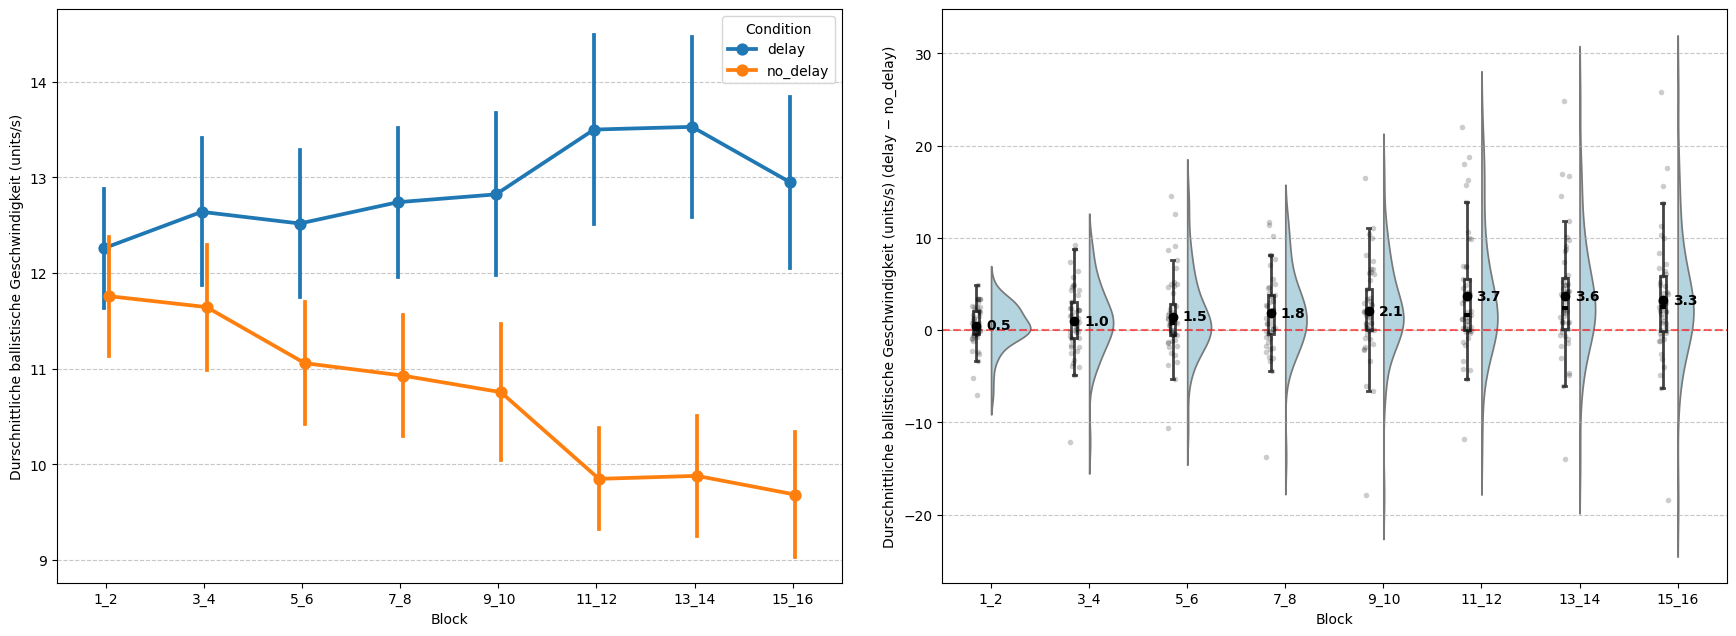

In [8]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_avg_ballistic_speed, 
    y_col="avg_ballistic_speed", 
    ylabel_left="Durschnittliche ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Durschnittliche ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=pair_order,
    base_size=10,
    decimals=1
)

## ANOVA: Ballistische Geschwindigkeit
Statistische Überprüfung, ob die Bedingung (Condition) und der zeitliche Verlauf (Pair) die ballistische Geschwindigkeit beeinflussen. Außerdem wird getestet, ob es eine Interaktion gibt – also ob die Bedingung je nach Trial-Paar unterschiedlich wirkt.

In [9]:
aov = pg.rm_anova(
    dv="avg_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source          SS  ddof1  ddof2          MS          F  \
0         condition  926.683516      1     48  926.683516  13.350710   
1              pair   40.962665      7    336    5.851809   2.122428   
2  condition * pair  254.475189      7    336   36.353598   6.835665   

          p_unc  p_GG_corr       np2       eps  
0  6.386093e-04   0.000639  0.217613  1.000000  
1  4.082263e-02   0.059945  0.042345  0.750824  
2  1.329395e-07   0.000467  0.124657  0.380191  


In [10]:
df_results_avg_speed = run_posthoc_analysis(df_diff_avg_ballistic_speed, "Avg. Ballistische Geschwindigkeit")


Post-hoc Ergebnisse für Avg. Ballistische Geschwindigkeit:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
11_12       9.849        3.699   13.500     6.889 3.651 3.872  0.001 0.553
13_14       9.881        4.412   13.528     6.593 3.648 3.977  0.001 0.568
15_16       9.685        4.543   12.949     6.272 3.264 3.423  0.003 0.489
  1_2      11.759        4.359   12.258     4.370 0.499 1.555  0.127 0.222
  3_4      11.645        4.574   12.640     5.369 0.995 1.861  0.079 0.266
  5_6      11.059        4.454   12.518     5.398 1.459 2.360  0.030 0.337
  7_8      10.929        4.419   12.741     5.451 1.812 2.888  0.012 0.413
 9_10      10.755        4.966   12.823     5.921 2.067 2.793  0.012 0.399


## Verlauf der maximalen ballistischen Geschwindigkeit
Visualisierung der Spitzen-Geschwindigkeit (`max_ballistic_speed`) über die verschiedenen Trial-Paare.

In [11]:
df_diff_max_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='max_ballistic_speed'
).reset_index()
df_diff_max_ballistic_speed['diff'] = df_diff_max_ballistic_speed['delay'] - df_diff_max_ballistic_speed['no_delay']

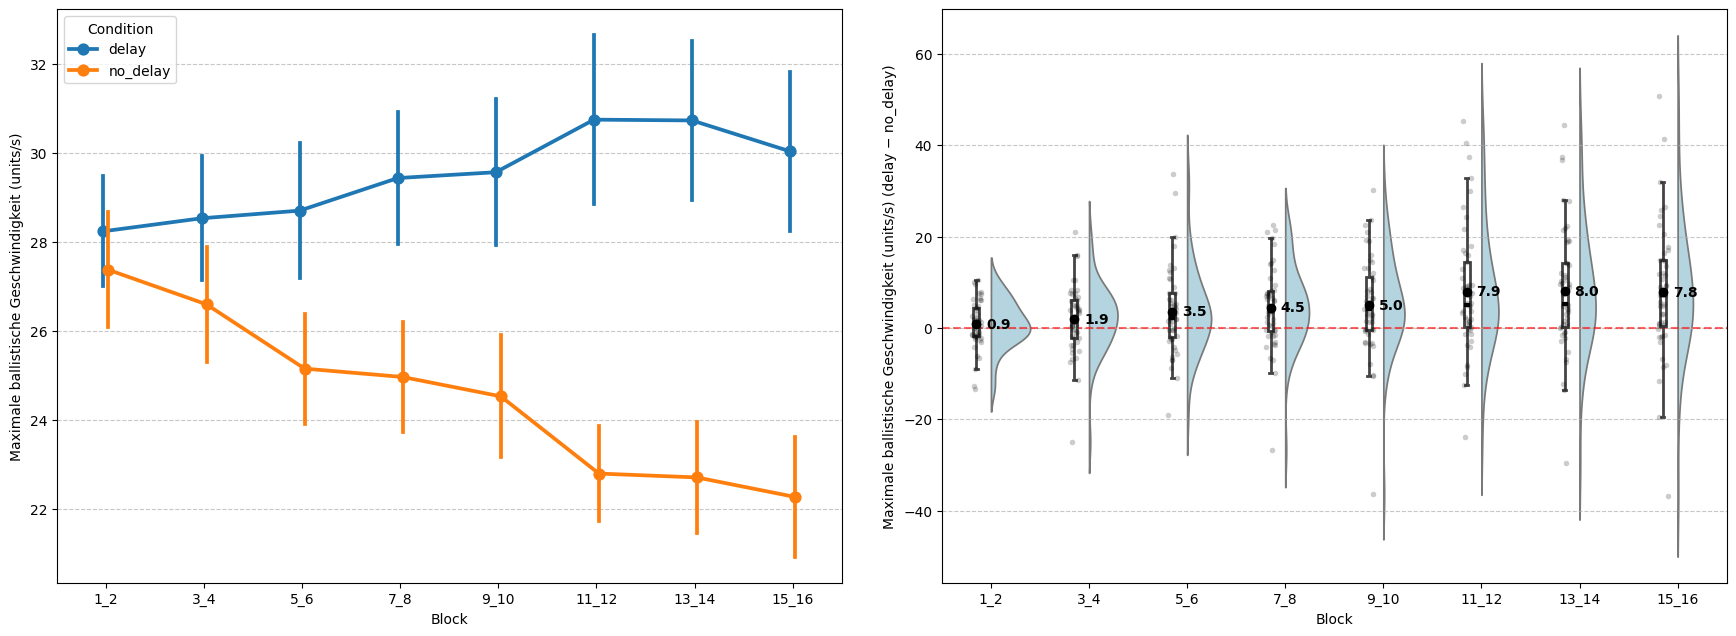

In [12]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_max_ballistic_speed, 
    y_col="max_ballistic_speed", 
    ylabel_left="Maximale ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Maximale ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=pair_order,
    base_size=10,
    decimals=1
)

In [13]:
df_results_max_speed = run_posthoc_analysis(df_diff_max_ballistic_speed, "Max. Ballistische Geschwindigkeit")


Post-hoc Ergebnisse für Max. Ballistische Geschwindigkeit:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
11_12      22.799        7.449   30.748    13.246 7.949 4.047  0.001 0.578
13_14      22.712        8.794   30.730    12.512 8.018 4.145  0.001 0.592
15_16      22.273        9.386   30.035    12.514 7.762 3.734  0.001 0.533
  1_2      27.375        9.064   28.241     8.652 0.866 1.156  0.253 0.165
  3_4      26.599        9.049   28.533     9.774 1.933 1.818  0.086 0.260
  5_6      25.156        8.663   28.704    10.597 3.549 2.632  0.015 0.376
  7_8      24.968        8.618   29.436    10.404 4.468 3.513  0.002 0.502
 9_10      24.533        9.567   29.567    11.497 5.034 3.284  0.003 0.469


In [14]:
aov = pg.rm_anova(
    dv="max_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source           SS  ddof1  ddof2           MS          F  \
0         condition  4797.509673      1     48  4797.509673  16.538947   
1              pair   182.360776      7    336    26.051539   1.938227   
2  condition * pair  1330.169203      7    336   190.024172   7.181757   

          p_unc  p_GG_corr       np2       eps  
0  1.763510e-04   0.000176  0.256263  1.000000  
1  6.295820e-02   0.092514  0.038812  0.679963  
2  5.119126e-08   0.000283  0.130147  0.387910  


## Analyse des Startzeitpunkts der ballistischen Phase
Dieser Plot zeigt die Dauer bis zum Beginn der ballistischen Phase (`time_to_ballistic_start`). Damit untersuchen wir, ob das Delay einen Einfluss darauf hat, wie schnell die Probanden die eigentliche Zielbewegung starten.

In [15]:
df_diff_ballistic_start = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='time_to_ballistic_start'
).reset_index()
df_diff_ballistic_start['diff'] = df_diff_ballistic_start['delay'] - df_diff_ballistic_start['no_delay']

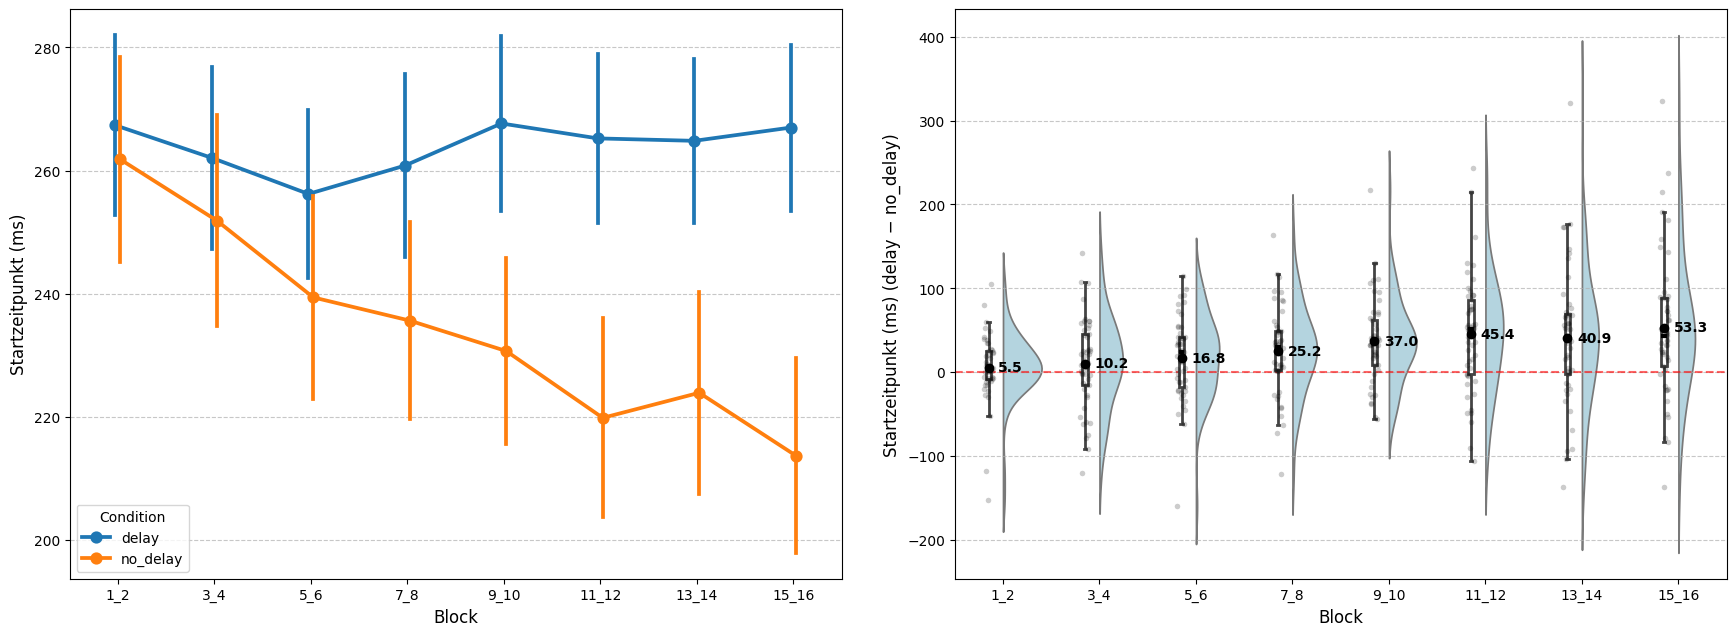

In [16]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_start, 
    y_col="time_to_ballistic_start", 
    ylabel_left="Startzeitpunkt (ms)", 
    ylabel_right="Startzeitpunkt (ms) (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=1
)

In [17]:
aov = pg.rm_anova(
    dv="time_to_ballistic_start",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source             SS  ddof1  ddof2             MS          F  \
0         condition  167895.561177      1     48  167895.561177  20.011392   
1              pair   43655.013460      7    336    6236.430494   5.113334   
2  condition * pair   52173.825479      7    336    7453.403640   7.272781   

          p_unc  p_GG_corr       np2       eps  
0  4.717223e-05   0.000047  0.294236  1.000000  
1  1.538058e-05   0.000317  0.096272  0.647937  
2  3.983665e-08   0.000020  0.131580  0.563136  


In [18]:
df_results_ball_start = run_posthoc_analysis(df_diff_ballistic_start, "Startzeitpunkt ball. Phase")


Post-hoc Ergebnisse für Startzeitpunkt ball. Phase:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
11_12     219.869      113.126  265.239    95.895 45.369 4.558  0.000 0.651
13_14     223.940      114.869  264.845    93.089 40.905 3.506  0.002 0.501
15_16     213.751      110.580  267.002    94.290 53.251 4.378  0.000 0.625
  1_2     261.830      116.861  267.358   102.438  5.528 0.948  0.348 0.135
  3_4     251.898      119.578  262.069   103.237 10.171 1.336  0.215 0.191
  5_6     239.425      115.262  256.221    95.845 16.796 2.364  0.030 0.338
  7_8     235.656      112.020  260.826   103.813 25.170 3.328  0.003 0.475
 9_10     230.713      106.052  267.666    99.094 36.953 5.099  0.000 0.728


In [19]:
mean_by_block_delay = stat_df.groupby(["pair", "condition"])["time_to_ballistic_start"].mean().reset_index()

print(mean_by_block_delay)

     pair condition  time_to_ballistic_start
0   11_12     delay               265.238736
1   11_12  no_delay               219.869308
2   13_14     delay               264.845141
3   13_14  no_delay               223.940359
4   15_16     delay               267.001724
5   15_16  no_delay               213.750866
6     1_2     delay               267.357519
7     1_2  no_delay               261.829855
8     3_4     delay               262.069037
9     3_4  no_delay               251.897660
10    5_6     delay               256.221284
11    5_6  no_delay               239.425231
12    7_8     delay               260.825881
13    7_8  no_delay               235.656229
14   9_10     delay               267.666101
15   9_10  no_delay               230.712710


In [20]:
df_diff_verification_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='verification_duration'
).reset_index()
df_diff_verification_duration['diff'] = df_diff_verification_duration['delay'] - df_diff_verification_duration['no_delay']

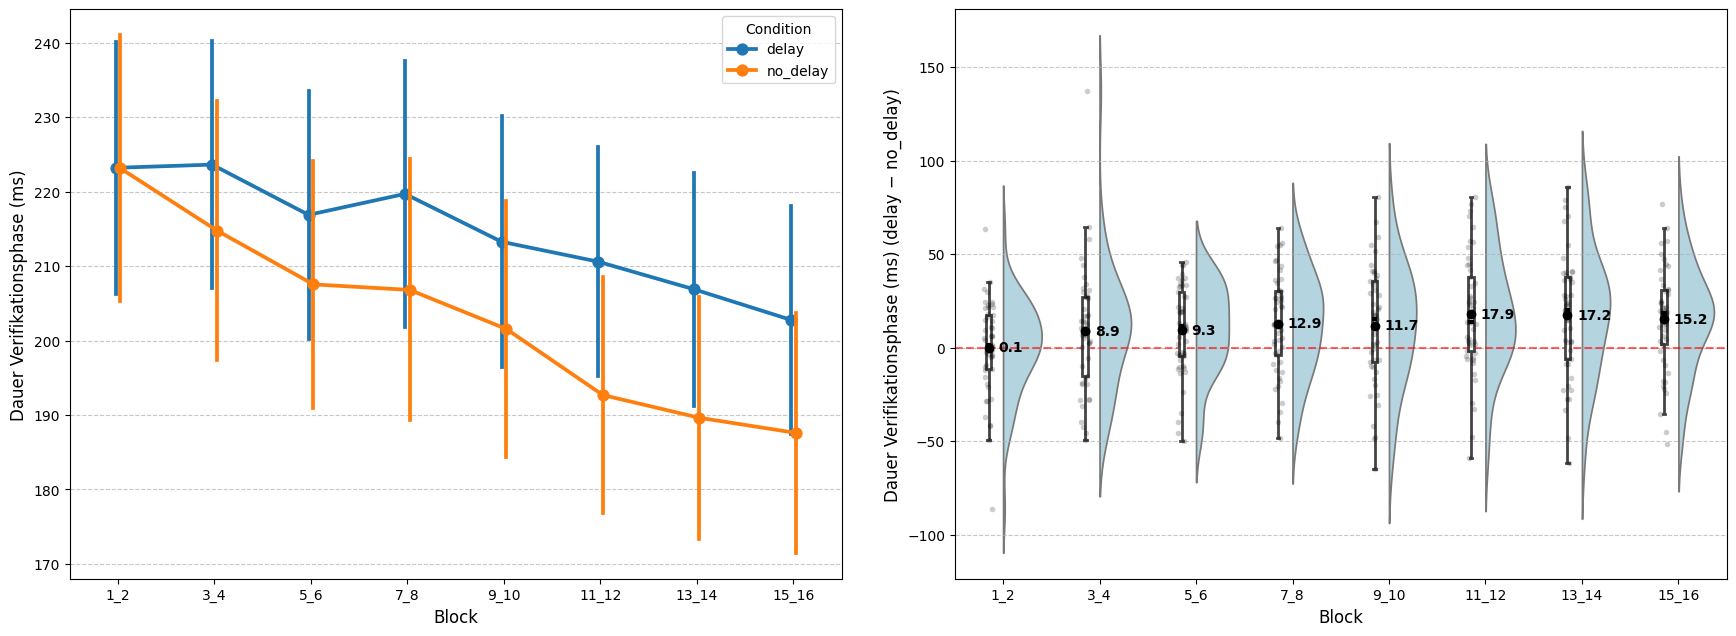

In [21]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_verification_duration, 
    y_col="verification_duration", 
    ylabel_left="Dauer Verifikationsphase (ms)", 
    ylabel_right="Dauer Verifikationsphase (ms) (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=1
)

In [22]:
aov = pg.rm_anova(
    dv="verification_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source            SS  ddof1  ddof2            MS          F  \
0         condition  26624.518958      1     48  26624.518958  19.955773   
1              pair  68245.289881      7    336   9749.327126   4.944304   
2  condition * pair   5683.823434      7    336    811.974776   2.780825   

      p_unc  p_GG_corr       np2       eps  
0  0.000048   0.000048  0.293658  1.000000  
1  0.000024   0.001523  0.093387  0.496282  
2  0.007993   0.017157  0.054761  0.737266  


In [23]:
df_results_verification_duration = run_posthoc_analysis(df_diff_verification_duration, "verification_duration")


Post-hoc Ergebnisse für verification_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
11_12     192.674      111.348  210.597   107.788 17.923 4.038  0.001 0.577
13_14     189.620      113.681  206.863   109.169 17.243 3.713  0.001 0.530
15_16     187.592      112.826  202.773   107.229 15.182 3.865  0.001 0.552
  1_2     223.135      125.182  223.203   118.217  0.068 0.019  0.985 0.003
  3_4     214.779      121.810  223.634   116.467  8.855 1.903  0.072 0.272
  5_6     207.544      116.345  216.882   116.606  9.338 2.723  0.014 0.389
  7_8     206.795      122.724  219.703   124.992 12.909 3.400  0.003 0.486
 9_10     201.549      120.132  213.270   118.096 11.721 2.617  0.016 0.374


In [24]:
mean_by_block_delay = stat_df.groupby(["pair", "condition"])["verification_duration"].mean().reset_index()

print(mean_by_block_delay)

     pair condition  verification_duration
0   11_12     delay             210.597303
1   11_12  no_delay             192.673842
2   13_14     delay             206.863308
3   13_14  no_delay             189.619913
4   15_16     delay             202.773380
5   15_16  no_delay             187.591744
6     1_2     delay             223.203329
7     1_2  no_delay             223.134867
8     3_4     delay             223.633704
9     3_4  no_delay             214.778902
10    5_6     delay             216.882339
11    5_6  no_delay             207.543930
12    7_8     delay             219.703328
13    7_8  no_delay             206.794567
14   9_10     delay             213.270051
15   9_10  no_delay             201.548854


In [25]:
df_diff_undershoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='undershoots'
).reset_index()
df_diff_undershoots['diff'] = df_diff_undershoots['delay'] - df_diff_undershoots['no_delay']

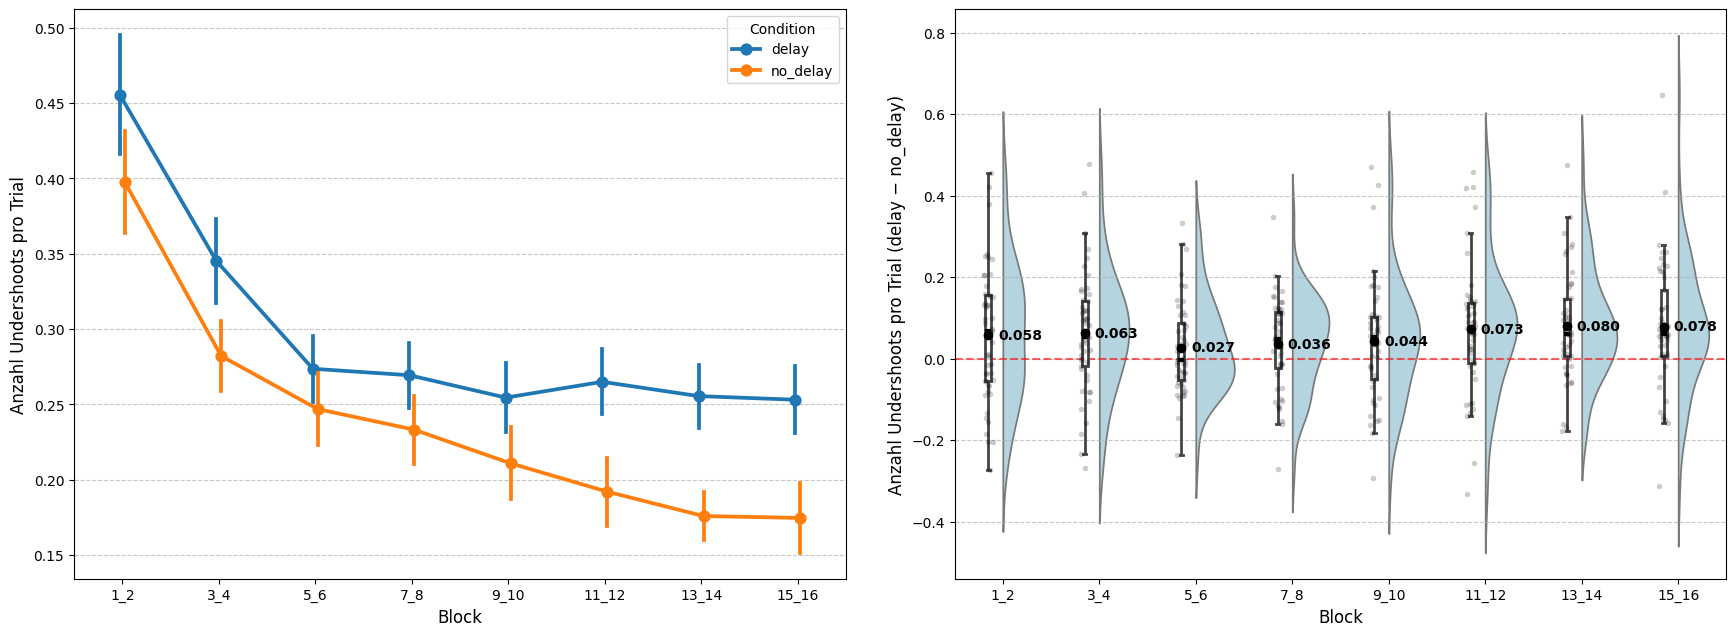

In [26]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_undershoots, 
    y_col="undershoots", 
    ylabel_left="Anzahl Undershoots pro Trial", 
    ylabel_right="Anzahl Undershoots pro Trial (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=3
)

In [27]:
aov = pg.rm_anova(
    dv="undershoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F  \
0         condition  0.642529      1     48  0.642529  19.464740   
1              pair  3.528632      7    336  0.504090  27.602001   
2  condition * pair  0.068283      7    336  0.009755   1.390138   

          p_unc     p_GG_corr       np2       eps  
0  5.775404e-05  5.775404e-05  0.288517  1.000000  
1  6.684857e-30  3.022022e-15  0.365096  0.467761  
2  2.084417e-01  2.231263e-01  0.028146  0.790229  


In [28]:
df_results_undershoots = run_posthoc_analysis(df_diff_undershoots, "undershoots")


Post-hoc Ergebnisse für undershoots:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
11_12       0.192        0.158    0.265     0.151 0.073 3.231  0.006 0.462
13_14       0.176        0.110    0.256     0.146 0.080 4.229  0.001 0.604
15_16       0.175        0.162    0.253     0.157 0.078 3.445  0.005 0.492
  1_2       0.398        0.236    0.455     0.276 0.058 2.461  0.028 0.352
  3_4       0.282        0.163    0.345     0.197 0.063 2.992  0.009 0.427
  5_6       0.247        0.167    0.274     0.154 0.027 1.648  0.106 0.235
  7_8       0.233        0.158    0.269     0.150 0.036 2.215  0.042 0.316
 9_10       0.211        0.167    0.255     0.160 0.044 2.059  0.051 0.294


In [29]:
df_diff_overshoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='overshoots'
).reset_index()
df_diff_overshoots['diff'] = df_diff_overshoots['delay'] - df_diff_overshoots['no_delay']

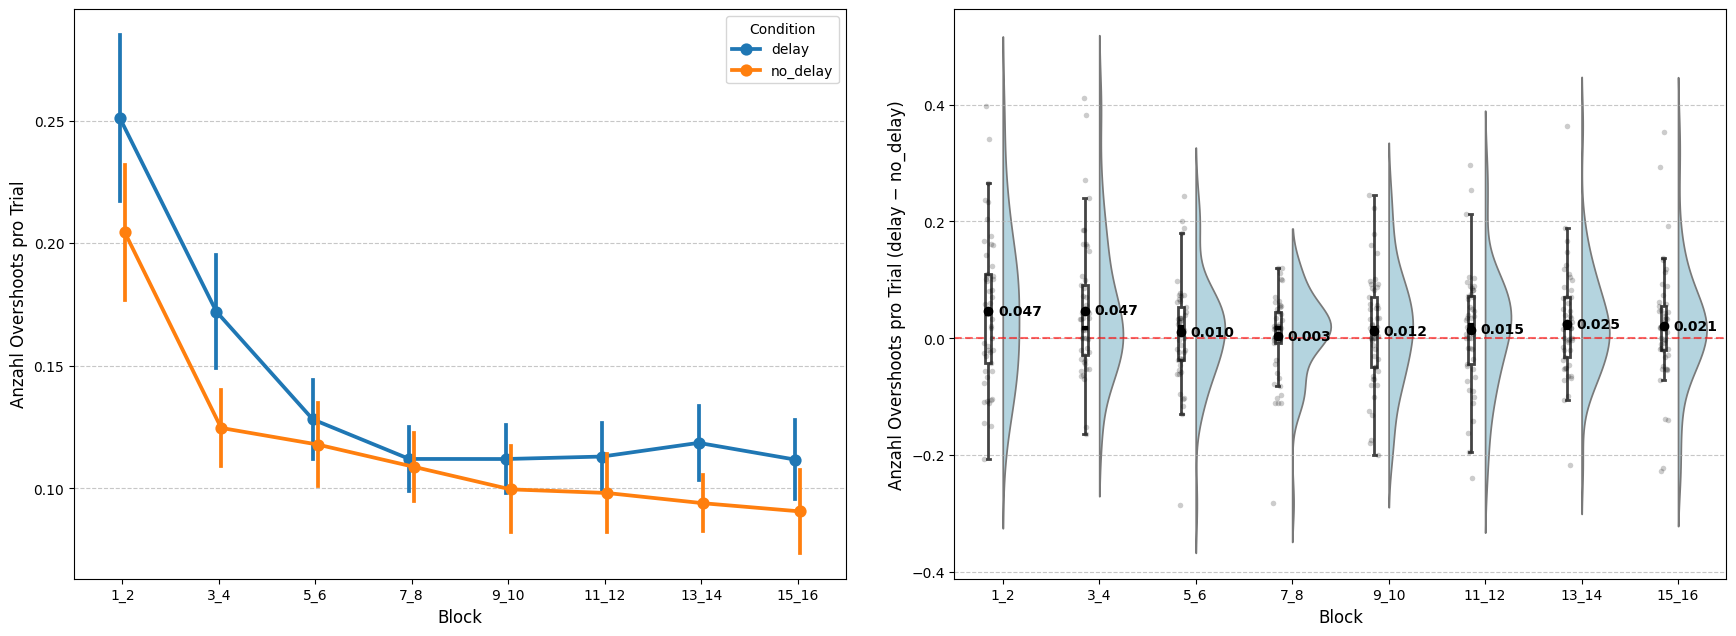

In [30]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_overshoots, 
    y_col="overshoots", 
    ylabel_left="Anzahl Overshoots pro Trial", 
    ylabel_right="Anzahl Overshoots pro Trial (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=3
)

In [31]:
aov = pg.rm_anova(
    dv="overshoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F  \
0         condition  0.099835      1     48  0.099835   9.277456   
1              pair  1.264087      7    336  0.180584  14.622549   
2  condition * pair  0.046323      7    336  0.006618   1.539289   

          p_unc     p_GG_corr       np2       eps  
0  3.761915e-03  3.761915e-03  0.161974  1.000000  
1  1.237697e-16  7.060970e-07  0.233503  0.327009  
2  1.529906e-01  1.715293e-01  0.031072  0.786264  


In [32]:
df_results_overshoots = run_posthoc_analysis(df_diff_overshoots, "overshoots")


Post-hoc Ergebnisse für overshoots:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
11_12       0.098        0.112    0.113     0.095 0.015 1.029  0.489 0.147
13_14       0.094        0.080    0.119     0.107 0.025 1.900  0.169 0.271
15_16       0.091        0.118    0.112     0.112 0.021 1.449  0.308 0.207
  1_2       0.205        0.192    0.251     0.236 0.047 2.529  0.059 0.361
  3_4       0.125        0.108    0.172     0.163 0.047 2.863  0.050 0.409
  5_6       0.118        0.120    0.128     0.112 0.010 0.800  0.489 0.114
  7_8       0.109        0.096    0.112     0.091 0.003 0.310  0.758 0.044
 9_10       0.100        0.123    0.112     0.098 0.012 0.897  0.489 0.128


In [33]:
df_diff_correction_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='correction_duration'
).reset_index()
df_diff_correction_duration['diff'] = df_diff_correction_duration['delay'] - df_diff_correction_duration['no_delay']

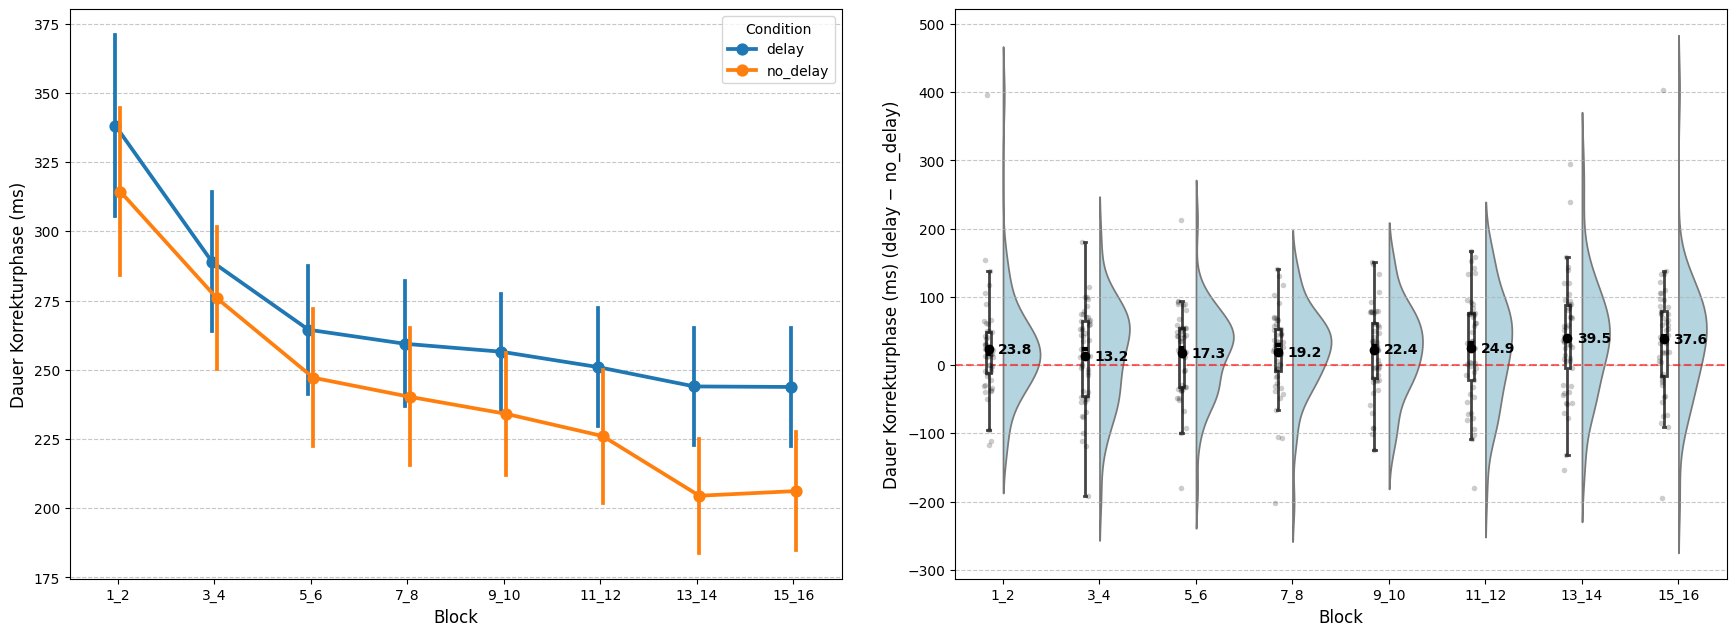

In [34]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_correction_duration, 
    y_col="correction_duration", 
    ylabel_left="Dauer Korrekturphase (ms)", 
    ylabel_right="Dauer Korrekturphase (ms) (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=1
)

In [35]:
aov = pg.rm_anova(
    dv="correction_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source             SS  ddof1  ddof2             MS          F  \
0         condition  119910.602090      1     48  119910.602090  11.470403   
1              pair  790318.860805      7    336  112902.694401  15.450522   
2  condition * pair   14919.081241      7    336    2131.297320   1.324972   

          p_unc     p_GG_corr       np2       eps  
0  1.419207e-03  1.419207e-03  0.192876  1.000000  
1  1.508918e-17  5.465657e-09  0.243505  0.442901  
2  2.374585e-01  2.504998e-01  0.026862  0.777061  


In [36]:
df_results_correction_duration = run_posthoc_analysis(df_diff_correction_duration, "correction_duration")


Post-hoc Ergebnisse für correction_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
11_12     226.031      168.007  250.966   148.958 24.935 2.248  0.048 0.321
13_14     204.495      144.408  243.966   147.130 39.471 3.312  0.014 0.473
15_16     206.171      149.671  243.779   150.283 37.607 3.028  0.016 0.433
  1_2     314.363      211.657  338.128   228.856 23.765 2.156  0.048 0.308
  3_4     275.850      179.441  289.006   175.254 13.156 1.285  0.205 0.184
  5_6     247.117      173.242  264.457   162.137 17.340 1.906  0.072 0.272
  7_8     240.215      172.958  259.373   158.509 19.158 2.166  0.048 0.309
 9_10     234.056      154.700  256.500   146.531 22.444 2.516  0.041 0.359


In [37]:
df_diff_ballistic_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='ballistic_duration'
).reset_index()
df_diff_ballistic_duration['diff'] = df_diff_ballistic_duration['delay'] - df_diff_ballistic_duration['no_delay']

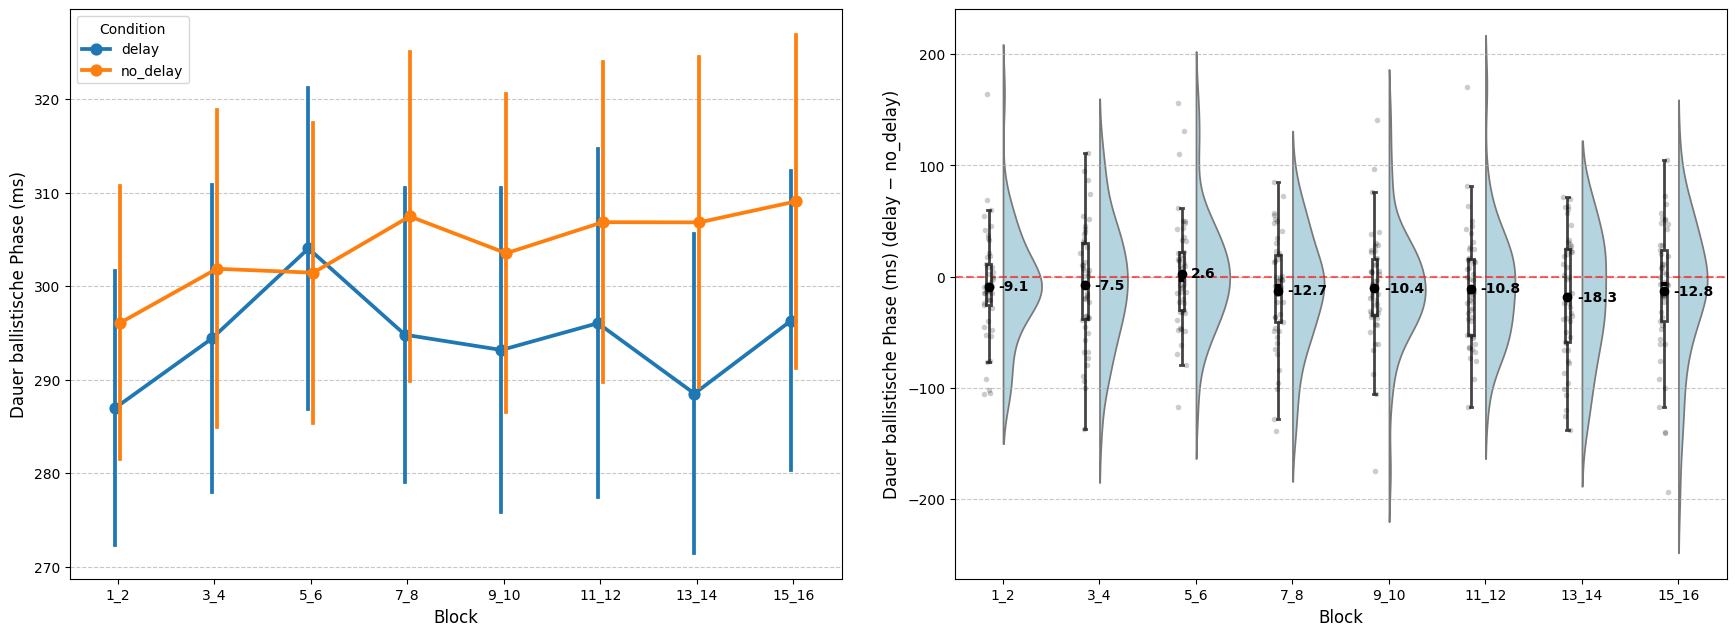

In [38]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_duration, 
    y_col="ballistic_duration", 
    ylabel_left="Dauer ballistische Phase (ms)", 
    ylabel_right="Dauer ballistische Phase (ms) (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=1
)

In [39]:
aov = pg.rm_anova(
    dv="ballistic_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source            SS  ddof1  ddof2            MS         F  \
0         condition  19040.220495      1     48  19040.220495  3.601579   
1              pair   9433.403063      7    336   1347.629009  0.657114   
2  condition * pair   6134.366390      7    336    876.338056  1.110633   

      p_unc  p_GG_corr       np2       eps  
0  0.063748   0.063748  0.069796  1.000000  
1  0.708345   0.595527  0.013505  0.476816  
2  0.355819   0.355698  0.022615  0.758836  


In [40]:
df_results_ballistic_duration = run_posthoc_analysis(df_diff_ballistic_duration, "ballistic_duration")


Post-hoc Ergebnisse für ballistic_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay    Diff      t  p_adj      d
11_12     306.839      119.937  296.035   130.139 -10.804 -1.503  0.238 -0.215
13_14     306.818      123.628  288.501   119.246 -18.318 -2.315  0.200 -0.331
15_16     309.056      124.478  296.289   111.984 -12.767 -1.507  0.238 -0.215
  1_2     296.080      102.354  286.988   102.545  -9.091 -1.318  0.258 -0.188
  3_4     301.854      118.764  294.401   114.747  -7.453 -0.989  0.374 -0.141
  5_6     301.432      112.460  304.025   119.990   2.593  0.363  0.718  0.052
  7_8     307.456      123.261  294.801   110.057 -12.656 -1.790  0.238 -0.256
 9_10     303.518      119.110  293.165   121.587 -10.353 -1.468  0.238 -0.210


In [41]:
df_diff_auc = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='auc'
).reset_index()
df_diff_auc['diff'] = df_diff_auc['delay'] - df_diff_auc['no_delay']

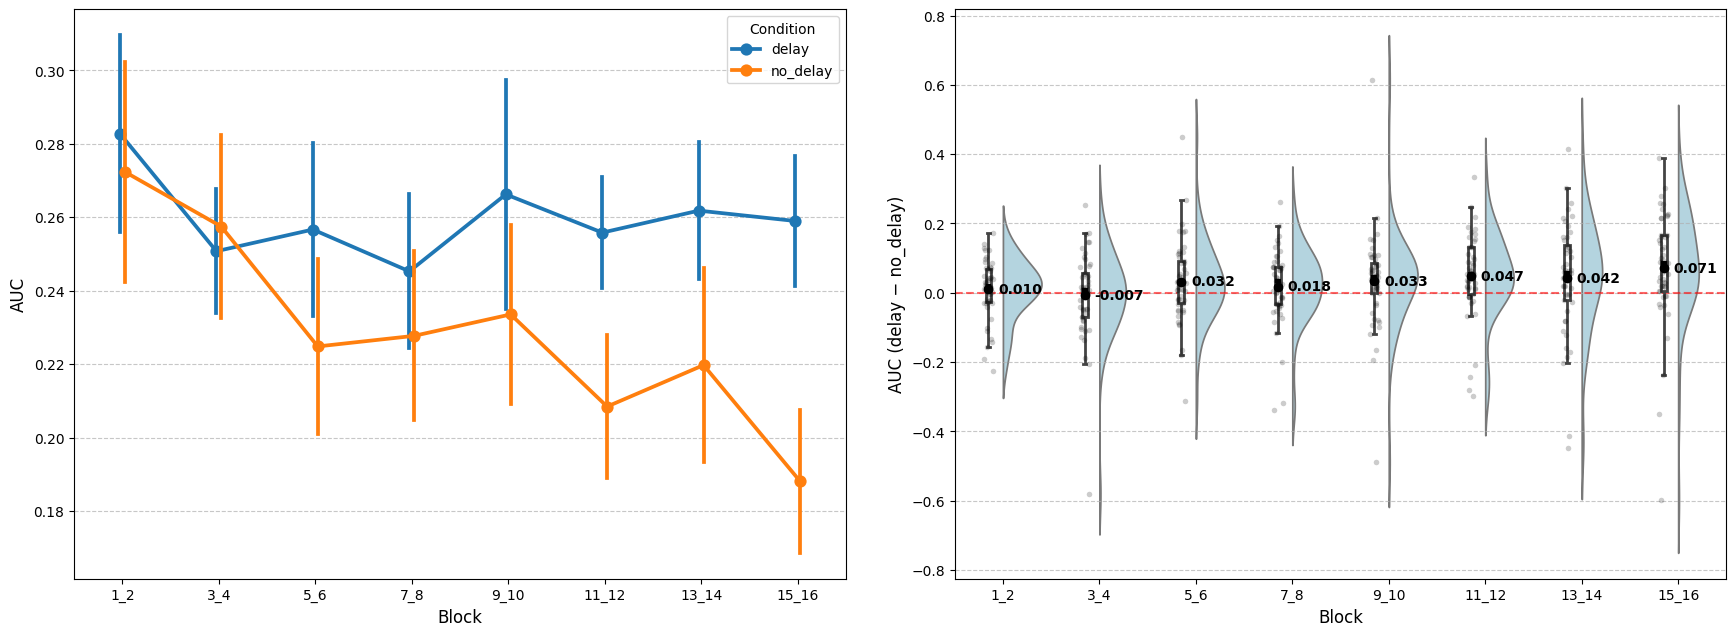

In [42]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_auc, 
    y_col="auc", 
    ylabel_left="AUC", 
    ylabel_right="AUC (delay − no_delay)",
    pair_order=pair_order,
    base_size=12,
    decimals=3
)

In [43]:
aov = pg.rm_anova(
    dv="auc",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True,
    effsize="np2"
)

print(aov)

             Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         condition  0.185524      1     48  0.185524  6.273057  0.015708   
1              pair  0.186203      7    336  0.026600  2.797487  0.007660   
2  condition * pair  0.098301      7    336  0.014043  2.466448  0.017652   

   p_GG_corr       np2       eps  
0   0.015708  0.115583  1.000000  
1   0.028877  0.055071  0.553391  
2   0.043348  0.048873  0.600601  


In [44]:
df_results_auc = run_posthoc_analysis(df_diff_auc, "auc")


Post-hoc Ergebnisse für auc:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff      t  p_adj      d
11_12       0.208        0.136    0.256     0.106  0.047  2.690  0.039  0.384
13_14       0.220        0.184    0.262     0.130  0.042  1.818  0.151  0.260
15_16       0.188        0.137    0.259     0.123  0.071  2.986  0.036  0.427
  1_2       0.272        0.210    0.283     0.188  0.010  0.851  0.456  0.122
  3_4       0.257        0.175    0.251     0.118 -0.007 -0.369  0.713 -0.053
  5_6       0.225        0.167    0.257     0.164  0.032  1.868  0.151  0.267
  7_8       0.228        0.161    0.245     0.147  0.018  1.114  0.361  0.159
 9_10       0.234        0.171    0.266     0.218  0.033  1.625  0.177  0.232
